In [1]:
import torch
import torch.nn as nn
from jupyterlab.labextensions import enable_aliases

from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.transforms import v2

import sys
import os
import matplotlib.pyplot as plt
import numpy as np

import json
from tqdm import tqdm
from PIL import Image

plt.style.use('dark_background')

In [2]:
# Определяем устройство для работы
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Задача классификации

In [3]:
class MNISTDataset(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.len_dataset = 0
        self.data_list = []

        for path_dir, dir_list, file_list in os.walk(path):
            if path_dir == path:
                self.classes = sorted(dir_list)
                self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
                continue

            if sys.platform == 'linux':
                cls = path_dir.split('/')[-1]
            elif sys.platform == 'win32':
                cls = path_dir.split('\\')[-1]

            for name_file in file_list:
                file_path = os.path.join(path_dir, name_file)
                self.data_list.append((file_path, self.class_to_idx[cls]))

            self.len_dataset += len(file_list)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        file_path, target = self.data_list[index]
        sample = np.array(Image.open(file_path))

        if self.transform is not None:
            sample = self.transform(sample)

        return sample, target

In [4]:
# Преобразования для изображения
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,), std=(0.5,))
    ]
)

In [5]:
# Создание датасетов
train_data = MNISTDataset('./drive/MyDrive/Colab_Notebooks/content/mnist/training', transform=transform) if 'google.colab' in sys.modules \
    else MNISTDataset('/Users/SashaCurry/ML_content/mnist/training', transform=transform)
    # else MNISTDataset('/Users/SashaCurry/PyCharmMiscProject/content/mnist/training', transform=transform)
test_data = MNISTDataset('./drive/MyDrive/Colab_Notebooks/content/mnist/training', transform=transform) if 'google.colab' in sys.modules \
    else MNISTDataset('/Users/SashaCurry/ML_content/mnist/testing', transform=transform)
    # else MNISTDataset('/Users/SashaCurry/PyCharmMiscProject/content/mnist/training', transform=transform)

In [6]:
train_data, val_data = random_split(train_data, [0.7, 0.3])

In [7]:
# Создание загрузчиков
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


In [8]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.activation(x)
        out = self.layer_2(x)
        return out

model = MyModel(784, 10).to(device)

In [9]:
# Проверяем правильность модели
input = torch.rand([16, 784], dtype=torch.float32).to(device)

out = model(input)
print(out.shape)

torch.Size([16, 10])


In [10]:
# Выбор фунцкии потерь и оптимизатор ГС
loss_model = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_sheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)

In [ ]:
EPOCHS = 50
train_loss = []
train_acc = []
val_loss = []
val_acc = []
lr_list = []
best_loss = None
count = 0

# Цикл обучения
for epoch in range(EPOCHS):
    # Тренировка модели
    running_train_loss = []
    mean_train_loss = 0
    train_loop = tqdm(train_loader, leave=False) # создание progress bar
    true_answer = 0

    model.train()
    for x, targets in train_loop:
        # Данные
        # (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.reshape(-1, 28*28).to(device)
        # (batch_size, int) -> (batch_size, 10), dtype=float32
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()
        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()

        train_loop.set_description(f'Epoch [{epoch+1}/{EPOCHS}], train_loss={mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer / len(train_data)

    # Сохранение значения функции потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        mean_val_loss = 0
        for x, targets in val_loader:
            # Данные
            # (batch_size, 1, 28, 28) -> (batch_size, 784)
            x = x.reshape(-1, 28*28).to(device)
            # (batch_size, int) -> (batch_size, 10), dtype=float32
            targets = targets.reshape(-1).to(torch.int32)
            targets = torch.eye(10)[targets].to(device)

            # Прямой проход + расчет ошибки модели
            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)

            true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()

        # Расчет значения метрики
        running_val_acc = true_answer / len(val_data)

        # Сохранение значения функции потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        lr_sheduler.step(mean_val_loss)
        lr = opt.param_groups[0]['lr']
        lr_list.append(lr)

        print(f'Epoch [{epoch+1}/{EPOCHS}]: train_loss={mean_train_loss:.4f}, train_acc={running_train_acc:.4f}, val_loss={mean_val_loss:.4f}, val_acc={running_val_acc:.4f}')

        if best_loss is None:
            best_loss = mean_val_loss

        if mean_val_loss < best_loss:
            best_loss = mean_val_loss
            count = 0

            checkpoint = {
                'state_model': model.state_dict(),
                'state_opt': opt.state_dict(),
                'state_lr_scheduler': lr_sheduler.state_dict(),
                'loss': {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'best_loss': best_loss
                },
                'metric': {
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                },
                'lr': lr_list,
                'epoch': {
                    'EPOCHS': EPOCHS,
                    'save_epoch': epoch
                }
            }

            torch.save(checkpoint, f'model_state_dict_epoch_{epoch+1}.pt')
            print(f'На эпохе - {epoch+1}, сохранена модель со значением функции потерь на валидации - {mean_val_loss:.4f}', end='\n\n')

        if count >= 10:
            print(f"\033[31mОбучение остановленно на {epoch + 1} эпохе.\033[0m")
            break

        count += 1

Epoch [1/50], train_loss=0.5701:  44%|████▎     | 286/657 [00:06<00:07, 46.55it/s]

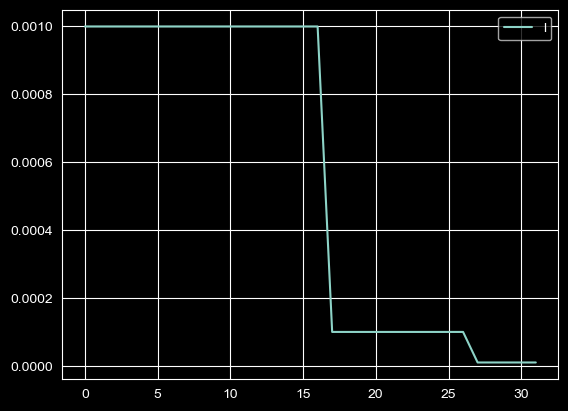

In [12]:
plt.plot(lr_list)
plt.legend('lr_list')
plt.show()

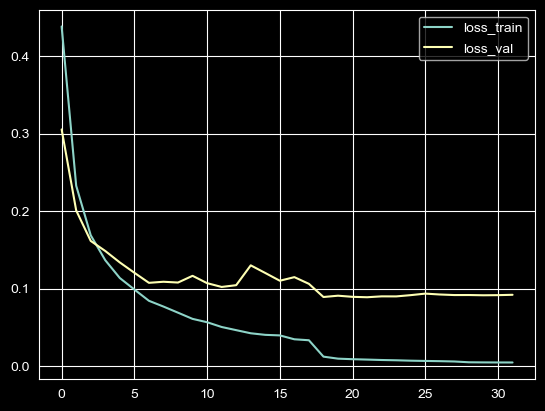

In [13]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['loss_train', 'loss_val'])
plt.show()

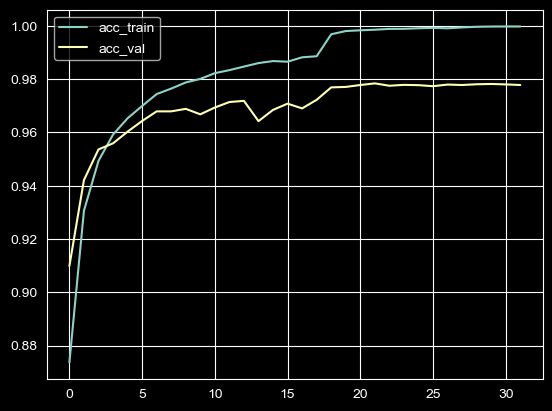

In [14]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['acc_train', 'acc_val'])
plt.show()

## Проверка модели на тестовой выборке

In [15]:
checkpoint = torch.load('./model_state_dict_epoch_22.pt')
model.load_state_dict(checkpoint['state_model'])

<All keys matched successfully>

In [16]:
model.eval()
with torch.no_grad():
    running_test_loss = []
    true_answer = 0
    for x, targets in test_loader:
        # Данные
        # (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.reshape(-1, 28*28).to(device)
        # (batch_size, int) -> (batch_size, 10), dtype=float32
        targets = targets.reshape(-1).to(torch.int32)
        targets = torch.eye(10)[targets].to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        running_test_loss.append(loss.item())
        mean_test_loss = sum(running_test_loss)/len(running_test_loss)

        true_answer += (pred.argmax(dim=1) == targets.argmax(dim=1)).sum().item()

    # Расчёт значения метрики
    running_test_acc = true_answer / len(test_data)

print(f'test_loss = {mean_test_loss:.4f}, test_acc = {running_test_acc:.4f}', end='\n\n')

test_loss = 0.0807, test_acc = 0.9777



# Задача регрессии

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [16]:
class EarlyStopping:
    def __init__(self, mode='min', patience=10, threshold=0.0001, threshold_mode='rel'):
        if mode not in {'min', 'max'}:
            raise ValueError(f"Параметр mode может принимать только значения max и min.")
        if threshold_mode not in {'rel', 'abs'}:
            raise ValueError(f"Параметр threshold_mode может принимать только значения rel и ads.")
        if not isinstance(patience, int):
            raise TypeError(f"Параметр patience должен быть целым числом.")
        if not isinstance(threshold, float):
            raise TypeError(f"Параметр threshold должен быть float и меньше 1.0.")
        if threshold >= 1.0:
            raise ValueError(f"Параметр threshold должен быть меньше 1.0.")

        self.mode = mode
        self.patience = patience
        self.threshold = threshold
        self.threshold_mode = threshold_mode
        self.count = 0
        self.best = None

    def __call__(self, tracked_parameter):
        current = float(tracked_parameter)
        if self.best is None:
            self.best = current
            return False

        if self.changed_better(current, self.best):
            self.best = current
            self.count = 0
        else:
            self.count += 1

        if self.count >= self.patience:
            self.count = 0
            return True
        return False

    def changed_better(self, current, best):
        if self.mode == 'min' and self.threshold_mode == 'rel':
            return current < best - best * self.threshold

        elif self.mode == 'min' and self.threshold_mode == 'abs':
            return current < best - self.threshold

        elif self.mode == 'max' and self.threshold_mode == 'rel':
            return current > best + best * self.threshold

        else:  # mode == 'max' and threshold_mode == 'abs':
            return current > best + self.threshold

## Создание данных

In [17]:
class DataSetReg(Dataset):
    def __init__(self, path, transform=None):
        self.path = path
        self.transform = transform

        self.list_name_file = os.listdir(path)
        if 'coords.json' in self.list_name_file:
            self.list_name_file.remove('coords.json')

        self.len_dataset = len(self.list_name_file)

        with open(os.path.join(self.path, 'coords.json'), 'r') as fl:
            self.dict_coords = json.load(fl)

    def __len__(self):
        return self.len_dataset

    def __getitem__(self, index):
        name_file = self.list_name_file[index]
        path_img = os.path.join(self.path, name_file)

        img = np.array(Image.open(path_img))
        coord = np.array(self.dict_coords[name_file])

        if self.transform is not None:
            img = self.transform(img)

        return img, coord

In [18]:
# Преобразования для изображения
transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=(0.5,), std=(0.5,))
    ]
)

In [19]:
dataset = DataSetReg('/drive/MyDrive/Colab_Notebooks/content/dataset/', transform=transform) if 'google.colab' in sys.modules \
    else DataSetReg('/Users/SashaCurry/PyCharmMiscProject/content/dataset/', transform=transform)
    # else DataSetReg('/Users/SashaCurry/PyCharmMiscProject/content/dataset/', transform=transform)

In [20]:
train_set, val_set, test_set = random_split(dataset, [0.7, 0.1, 0.2])

In [21]:
# Создание загрузчиков
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

## Создание модели

In [22]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.layer_1 = nn.Linear(input, 128)
        self.layer_2 = nn.Linear(128, output)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.activation(x)
        out = self.layer_2(x)
        return out


model = MyModel(64*64, 2).to(device)

In [23]:
# Проверяем правильность модели
input = torch.rand([16, 64*64], dtype=torch.float32).to(device)

out = model(input)
print(out.shape)

torch.Size([16, 2])


In [24]:
loss_model = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5)
earlystopping = EarlyStopping(mode='min', patience=10)

## Тренировка модели

In [25]:
EPOCHS = 100
train_loss = []
train_acc = []
val_loss = []
val_acc = []
lr_list = []
best_loss = None
best_epoch = None

In [26]:
# Цикл обучения
for epoch in range(EPOCHS):
    # Тренировка модели
    running_train_loss = []
    mean_train_loss = 0
    # train_loop = tqdm(train_loader, leave=False) # создание progress bar
    true_answer = 0

    model.train()
    # for x, targets in train_loop:
    for x, targets in train_loader:
        # Данные
        # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
        x = x.reshape(-1, 64*64).to(device)
        targets = targets.to(torch.float32).to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        # Обратный проход
        opt.zero_grad()
        loss.backward()
        # Шаг оптимизации
        opt.step()

        running_train_loss.append(loss.item())
        mean_train_loss = sum(running_train_loss) / len(running_train_loss)

        true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

        # train_loop.set_description(f'Epoch [{epoch+1}/{EPOCHS}], train_loss={mean_train_loss:.4f}')

    # Расчет значения метрики
    running_train_acc = true_answer / len(train_set)

    # Сохранение значения функции потерь и метрики
    train_loss.append(mean_train_loss)
    train_acc.append(running_train_acc)

    # Проверка модели (валидация)
    model.eval()
    with torch.no_grad():
        running_val_loss = []
        true_answer = 0
        for x, targets in val_loader:
            # Данные
            # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
            x = x.reshape(-1, 64*64).to(device)
            targets = targets.to(torch.float32).to(device)

            # Прямой проход + расчет ошибки модели
            pred = model(x)
            loss = loss_model(pred, targets)

            running_val_loss.append(loss.item())
            mean_val_loss = sum(running_val_loss) / len(running_val_loss)

            true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

        # Расчет значения метрики
        running_val_acc = true_answer / len(val_set)

        # Сохранение значения функции потерь и метрики
        val_loss.append(mean_val_loss)
        val_acc.append(running_val_acc)

        lr_scheduler.step(mean_val_loss)
        lr = opt.param_groups[0]['lr']
        lr_list.append(lr)

        print(f'Epoch [{epoch+1}/{EPOCHS}]: train_loss={mean_train_loss:.4f}, train_acc={running_train_acc:.4f}, val_loss={mean_val_loss:.4f}, val_acc={running_val_acc:.4f}, lr={lr:.4f}')

        if best_loss is None:
            best_loss = mean_val_loss
            best_epoch = epoch

        if mean_val_loss < best_loss:
            # if os.path.exists(f'model_state_dict_epoch_{best_epoch}.pt'):
            #     os.remove(f'model_state_dict_epoch_{best_epoch}.pt')

            best_loss = mean_val_loss
            best_epoch = epoch + 1

            checkpoint = {
                'state_model': model.state_dict(),
                'state_opt': opt.state_dict(),
                'state_lr_scheduler': lr_scheduler.state_dict(),
                'loss': {
                    'train_loss': train_loss,
                    'val_loss': val_loss,
                    'best_loss': best_loss
                },
                'metric': {
                    'train_acc': train_acc,
                    'val_acc': val_acc,
                },
                'lr': lr_list,
                'epoch': {
                    'EPOCHS': EPOCHS,
                    'save_epoch': epoch
                }
            }

            torch.save(checkpoint, f'model_state_dict_epoch_{best_epoch}.pt')
            print(f'На эпохе {epoch+1} сохранена модель со значением функции потерь на валидации = {mean_val_loss:.4f}')


        if earlystopping(mean_val_loss):
            print(f'\033[31mОбучение остановлено на {epoch+1} эпохе.\033[m')
            break

Epoch [1/100]: train_loss=1.9409, train_acc=0.6353, val_loss=0.1312, val_acc=0.6729, lr=0.0010
Epoch [2/100]: train_loss=0.1376, train_acc=0.6818, val_loss=0.1550, val_acc=0.6273, lr=0.0010
Epoch [3/100]: train_loss=0.1241, train_acc=0.7206, val_loss=0.0746, val_acc=0.8761, lr=0.0010
На эпохе 3 сохранена модель со значением функции потерь на валидации = 0.0746
Epoch [4/100]: train_loss=0.1082, train_acc=0.7683, val_loss=0.0896, val_acc=0.8218, lr=0.0010
Epoch [5/100]: train_loss=0.0976, train_acc=0.8004, val_loss=0.0755, val_acc=0.8678, lr=0.0010
Epoch [6/100]: train_loss=0.0852, train_acc=0.8392, val_loss=0.0814, val_acc=0.8529, lr=0.0010
Epoch [7/100]: train_loss=0.0777, train_acc=0.8636, val_loss=0.1047, val_acc=0.7648, lr=0.0010
Epoch [8/100]: train_loss=0.0710, train_acc=0.8856, val_loss=0.0689, val_acc=0.8790, lr=0.0010
На эпохе 8 сохранена модель со значением функции потерь на валидации = 0.0689
Epoch [9/100]: train_loss=0.0682, train_acc=0.8944, val_loss=0.0467, val_acc=0.9555,

In [ ]:
plt.plot(lr_list)
plt.legend('lr_list')
plt.show()

In [ ]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.legend(['loss_train', 'loss_val'])
plt.show()

In [ ]:
plt.plot(train_acc)
plt.plot(val_acc)
plt.legend(['acc_train', 'acc_val'])
plt.show()

## Проверка модели

In [ ]:
checkpoint = torch.load("/content/model_state_dict_epoch_62.pt")
model.load_state_dict(checkpoint['state_model'])

In [ ]:
model.eval()
with torch.no_grad():
    running_test_loss = []
    true_answer = 0
    for x, targets in test_loader:
        # Данные
        # (batch_size, 1, 64, 64) -> (batch_size, 64*64)
        x = x.reshape(-1, 64*64).to(device)
        targets = targets.to(device)

        # Прямой проход + расчет ошибки модели
        pred = model(x)
        loss = loss_model(pred, targets)

        running_test_loss.append(loss.item())
        mean_test_loss = sum(running_test_loss)/len(running_test_loss)

        true_answer += (torch.round(pred) == targets).all(dim=1).sum().item()

# Расчет значения метрики
running_test_acc = true_answer / len(test_set)

print(f'test_loss = {mean_test_loss:.4f}, test_acc={running_test_acc:.4f}')

In [ ]:
img, coord = test_set[100]

model.eval()

pred = model(img.view(1, 64*64).to(device)).detach().cpu()

x_pred = torch.round(pred[0])[1].item()
y_pred = torch.round(pred[0])[0].item()

print(f'Pred coord:          {pred[0]}')
print(f'\033[31mPred round-coord:\033[0m {torch.round(pred[0])}')
print(f'\033[32mTrue coord:\033[0m          {coord}')

plt.imshow(img[0].numpy(), cmap='gray')
plt.plot(x_pred, y_pred, marker='o', color='red')
plt.plot(coord[1].item(), coord[0].item(), marker='o', color='green')
plt.show()

In [ ]:
model.eval()
test_loader = DataLoader(test_set, batch_size=len(test_set))

x, targets = next(iter(test_loader))

print(x.shape)
print(targets.shape)

In [ ]:
pred = model(x.reshape(-1, 64*64).to(device)).detach().cpu()

index = ~(torch.round(pred) == targets).all(dim=1)
print(f"Из {len(test_set)} \033[31mНЕправильно\033[0m предсказано {index.sum()}.", end='\n\n')

imgs_false_pred = x[index]
false_pred = pred[index]
rel_false_pred = targets[index]

In [ ]:
index_false_pred = 1
false_coords = false_pred[index_false_pred]
rel_coords = rel_false_pred[index_false_pred]

print(f'Pred coord:          {false_coords}')
print(f'\033[31mPred round-coord:\033[0m {torch.round(false_coords)}')
print(f'\033[32mTrue coord:\033[0m          {rel_coords}')

x_pred = torch.round(false_coords)[1].item()
y_pred = torch.round(false_coords)[0].item()

plt.imshow(imgs_false_pred[index_false_pred][0].numpy(), cmap='gray')
plt.plot(x_pred, y_pred, marker='o', color='red')
plt.plot(rel_coords[1].item(), rel_coords[0].item(), marker='o', color='green')
plt.show()